# Real Dataset Analysis

This notebook explores the prepared NSL-KDD feature table and the cluster assignments generated by CyberTrace.

In [1]:
from pathlib import Path

import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

FEATURES_PATH = Path('../data/processed/features_nsl_kdd.csv')
CLUSTERS_PATH = Path('../reports/real_clusters.csv')
FIGURE_PATH = Path('../reports/figures/nsl_kdd_clusters.png')

In [2]:
features = pd.read_csv(FEATURES_PATH)
clusters = pd.read_csv(CLUSTERS_PATH)

features.shape, clusters.shape

((1011, 111), (1011, 6))

In [3]:
pd.crosstab(clusters['cluster'], clusters['label'])

label,benign,malicious
cluster,,
0,493,95
1,23,109
2,0,291


In [4]:
pd.crosstab(clusters['cluster'], clusters['attack_type'])

attack_type,back,buffer_overflow,guess_passwd,ipsweep,loadmodule,neptune,nmap,normal,pod,portsweep,rootkit,satan,smurf,teardrop,warezclient
cluster,,,,,,,,,,,,,,,
0,6,6,0,27,1,0,5,493,1,0,4,5,17,11,12
1,0,0,1,4,0,58,0,23,0,35,0,11,0,0,0
2,0,0,0,0,0,287,2,0,0,1,0,1,0,0,0


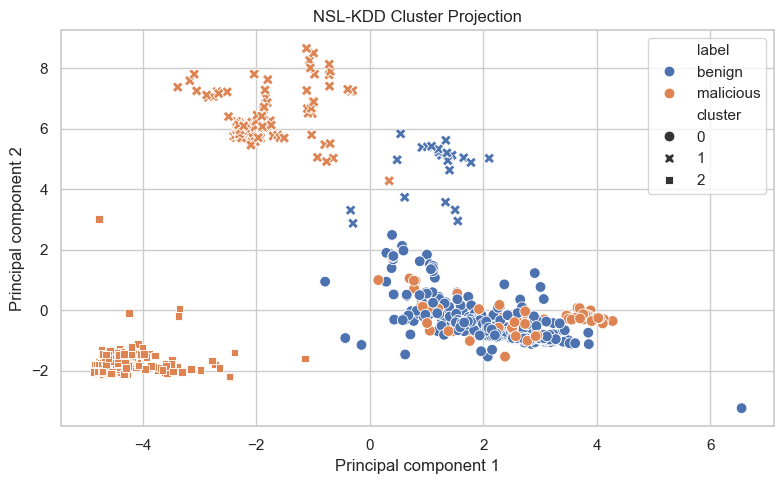

In [5]:
metadata_columns = {'sample_id', 'label', 'attack_type', 'source', 'difficulty'}
feature_columns = [column for column in features.columns if column not in metadata_columns]

scaled = StandardScaler().fit_transform(features[feature_columns])
points = PCA(n_components=2, random_state=42).fit_transform(scaled)
plot_df = clusters.assign(pc1=points[:, 0], pc2=points[:, 1])

sns.set_theme(style='whitegrid')
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=plot_df, x='pc1', y='pc2', hue='label', style='cluster', s=60, ax=ax)
ax.set_title('NSL-KDD Cluster Projection')
ax.set_xlabel('Principal component 1')
ax.set_ylabel('Principal component 2')
fig.tight_layout()

FIGURE_PATH.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(FIGURE_PATH, dpi=160)
plt.show()

## Interpretation Notes

- Cluster 0 is mostly benign in the baseline run.
- Cluster 1 is mixed but malicious-heavy.
- Cluster 2 is fully malicious in this sample.
- Labels are used for interpretation after clustering, not as inputs to the clustering algorithm.